# Time Series Analysis & Visualization in Python

Time series data is information collected in sequence over time. It shows how things change at different points, like stock prices every day or temperature every hour.

It is used in industries such as finance, pharmaceuticals, social media, and research.
Analyzing and visualizing this data helps us find trends, seasonal patterns, and behaviors.
These insights support forecasting and guide better decision-making.
The main goal is to study data in time order to extract meaningful patterns and predictions.

## Concepts in Time Series Analysis

- **Trend**: It represents the general direction in which a time series is moving over an extended period. It checks whether the values are increasing, decreasing or staying relatively constant.

- **Seasonality**: Seasonality refers to repetitive patterns or cycles that occur at regular intervals within a time series corresponding to specific time units like days, weeks, months or seasons.

- **Moving average**: It is used to smooth out short-term fluctuations and highlight longer-term trends or patterns in the data.

- **Noise**: It represents the irregular and unpredictable components in a time series that do not follow a pattern.

- **Differencing**: It is used to make the difference in values of a specified interval. By default it's 1 but we can specify different values for plots.

- **Stationarity**: A stationary time series is statistical properties such as mean, variance and autocorrelation remain constant over time.

- **Order**: The order of differencing refers to the number of times the time series data needs to be differenced to achieve stationarity.

- **Autocorrelation**: Autocorrelation is a statistical method used in time series analysis to quantify the degree of similarity between a time series and a lagged version of itself.

- **Resampling**: Resampling is a technique in time series analysis that is used for changing the frequency of the data observations.

## Types of Time Series Data

Time series data can be classified into two sections:

- **Continuous Time Series**: Data recorded at regular intervals with a continuous range of values like temperature, stock prices, Sensor Data, etc.
- **Discrete Time Series**: Data with distinct values or categories recorded at specific time points like counts of events, categorical statuses, etc.

## Visualization Approaches

- Use line plots or area charts for continuous data to highlight trends and fluctuations.
- Use bar charts or histograms for discrete data to show frequency or distribution across categories.

## Practical Time Series Visualization with Python

## <br>Step 1: Installing and Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

### Key Functions Explained:

- **`plot_acf`** (Autocorrelation Function Plot): Creates a visual representation of the autocorrelation between a time series and its lagged values. It helps identify how strongly current values are related to past values at different time lags, which is useful for detecting patterns and determining appropriate model parameters.

- **`adfuller`** (Augmented Dickey-Fuller Test): A statistical test used to check if a time series is stationary. It tests the null hypothesis that a unit root is present in the time series. If the p-value is less than a significance level (typically 0.05), we reject the null hypothesis and conclude the series is stationary.

## <br>Step 2: Loading the Dataset

In [3]:
df = pd.read_csv('stock_data.csv', parse_dates=True, index_col='Date')
df.head()


,Unnamed: 0,Open,High,Low,Close,Volume,Name
Date,,,,,,,
2006-01-03,NaN,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,NaN,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,NaN,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,NaN,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,NaN,43.10,43.66,42.82,43.42,16268338,AABA


### Parameters Explained:

- **`parse_dates=True`**: Automatically converts columns containing date strings into pandas datetime objects. This enables time-based operations like resampling, time-based indexing, and date arithmetic.

- **`index_col='Date'`**: Sets the 'Date' column as the DataFrame's index. This is essential for time series analysis as it allows pandas to recognize the temporal structure of the data and enables time-based slicing and operations.

## <br>Step 3: Cleaning of Data
We will drop columns from the dataset that are not important for our visualization.

In [10]:
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df.head()

,Open,High,Low,Close,Volume,Name,High_Diff,High_Smoothed
Date,,,,,,,,
2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA,0.68,NaN
2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA,-0.17,NaN
2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA,1.84,NaN
2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA,0.09,NaN
2006-01-10,42.96,43.34,42.34,42.98,16288580,AABA,-0.32,NaN


### Parameters Explained:

- **`columns=['Unnamed: 0']`**: Specifies which column(s) to remove from the DataFrame. 'Unnamed: 0' is typically an auto-generated index column from CSV files that we don't need for analysis.

- **`inplace=True`**: Modifies the original DataFrame directly instead of creating a new copy. Without this parameter, you would need to reassign the result back to the variable (e.g., `df = df.drop(...)`).

## <br>Step 4: Plotting High Stock Prices
Since the volume column is of continuous data type we will use line graph to visualize it.

**`sns.lineplot(data=df, x=df.index, y='High', label='High Price', color='blue')`**: Plots High prices over time using the datetime index on x-axis.

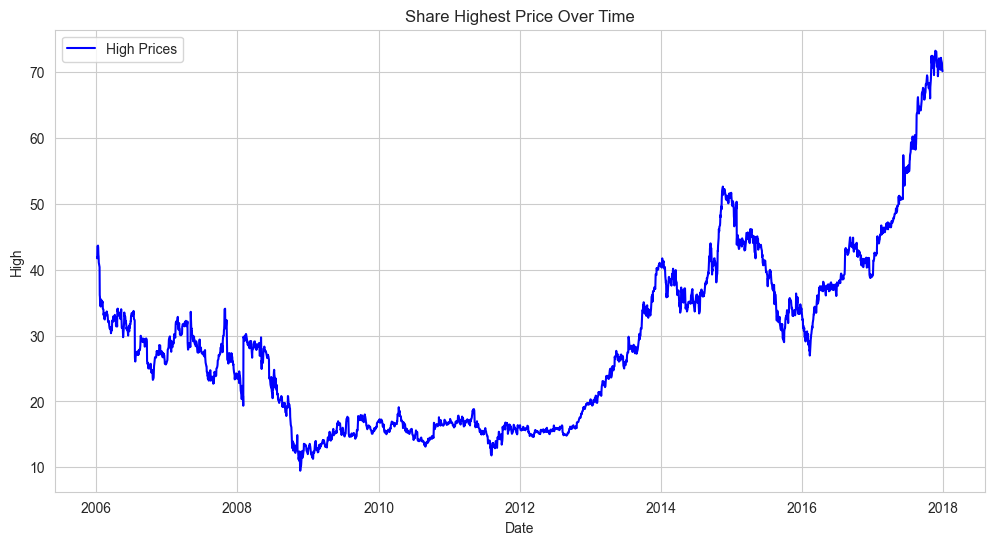

In [16]:
sns.set_style('whitegrid')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='High', label='High Prices', color='blue')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Share Highest Price Over Time')

plt.show()

## <br>Step 5: Resampling Data
To better understand the trend of the data we will use the resampling method which provide a clearer view of trends and patterns when we are dealing with daily data.

**`df_resampled = df.resample('M').mean(numeric_only=True)`**: Resamples data to monthly frequency and calculates the mean of all numeric columns for each month.

/var/folders/kl/q0f1lm215q3c6q3csphs0l3w0000gn/T/ipykernel_12758/3057350108.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_resampled = df.resample('M').mean(numeric_only=True)


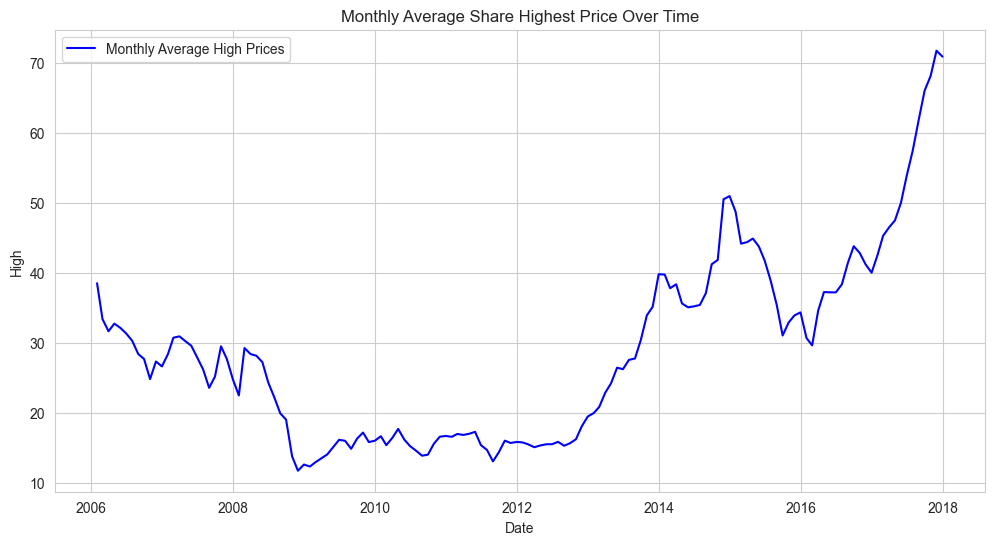

In [ ]:
df_resampled = df.resample('ME').mean(numeric_only=True)

sns.set_style('whitegrid')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_resampled, x='Date', y='High', label='Monthly Average High Prices', color='blue')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Monthly Average Share Highest Price Over Time')
plt.show()

### Parameters Explained:

- **`resample()`**: A pandas method that converts time series data from one frequency to another. It groups data by time periods and allows you to apply aggregation functions (like mean, sum, etc.) to each group.

- **`'ME'`**: Month End frequency offset alias. This tells resample to group data by calendar month boundaries, using the last day of each month as the timestamp. Other common aliases include 'D' (daily), 'W' (weekly), 'Q' (quarterly), 'Y' (yearly).

- **`numeric_only=True`**: Ensures that only numeric columns are included in the aggregation operation. This prevents errors when the DataFrame contains non-numeric columns (like strings or dates) that cannot be averaged.

## <br>Step 6: Differencing to Achieve Stationarity
Differencing involves subtracting the previous observation from the current observation to remove trends or seasonality.

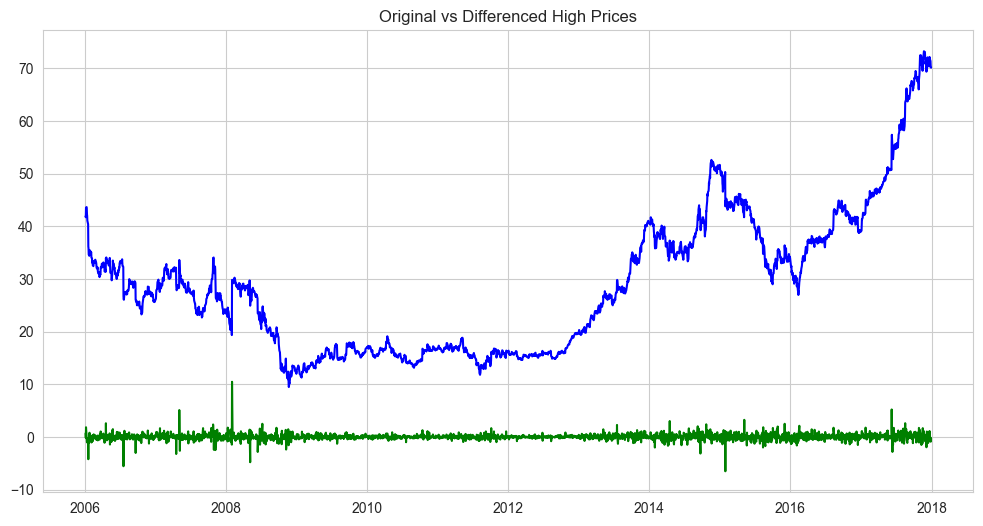

In [7]:
df['High_Diff'] = df['High'].diff()

# Printing the original and differenced data side by side we get:
df_combined = pd.concat([df['High'], df['High_Diff']], axis=1)
df_combined.head()

# As there is a NaN value we will drop that proceed with our test:
df.dropna(subset=['High_Diff'], inplace=True)
df['High_Diff'].head()

plt.figure(figsize=(12, 6))
plt.plot(df['High'], label='Original High Prices', color='blue')
plt.plot(df['High_Diff'], label='Differenced High Prices', linestyle='-', color='green')
plt.title('Original vs Differenced High Prices')
plt.show()

### Understanding the Components:

**`axis=1` Parameter:**
- In pandas, `axis=1` refers to the column axis (horizontal), while `axis=0` refers to the row axis (vertical)
- When using `pd.concat([df1, df2], axis=1)`, we combine DataFrames side by side, adding more columns
- This is useful for comparing two series in a single DataFrame

### How Differencing Works:

Differencing calculates the change between consecutive observations. For a time series: **Original → Differenced**

**Example with numbers:**
- Original values: [100, 105, 103, 108, 110]
- Differenced values: [NaN, 5, -2, 5, 2]

**Calculation:**
- Position 1: NaN (no previous value)
- Position 2: 105 - 100 = 5
- Position 3: 103 - 105 = -2
- Position 4: 108 - 103 = 5
- Position 5: 110 - 108 = 2

### Interpreting the Difference Plot:

**What we observe:**
- The **blue line** (original) shows the actual high prices with their trend
- The **green line** (differenced) shows the changes between consecutive days

**What we can learn:**
1. **Trend Removal**: The differenced series fluctuates around zero, indicating the trend has been removed
2. **Volatility**: Large spikes in the differenced series indicate days with significant price changes
3. **Stationarity**: If the differenced series has constant mean and variance, the data is now stationary
4. **Direction of Change**: Positive values = price increased; Negative values = price decreased
5. **Magnitude**: The size of the difference tells us how much the price changed

## <br>Step 7: Smoothing Data with Moving Average

**`df['High'].diff()`**: helps in calculating the difference between consecutive values in the High column. This differencing operation is used to transform a time series into a new series that represents the changes between consecutive observations.

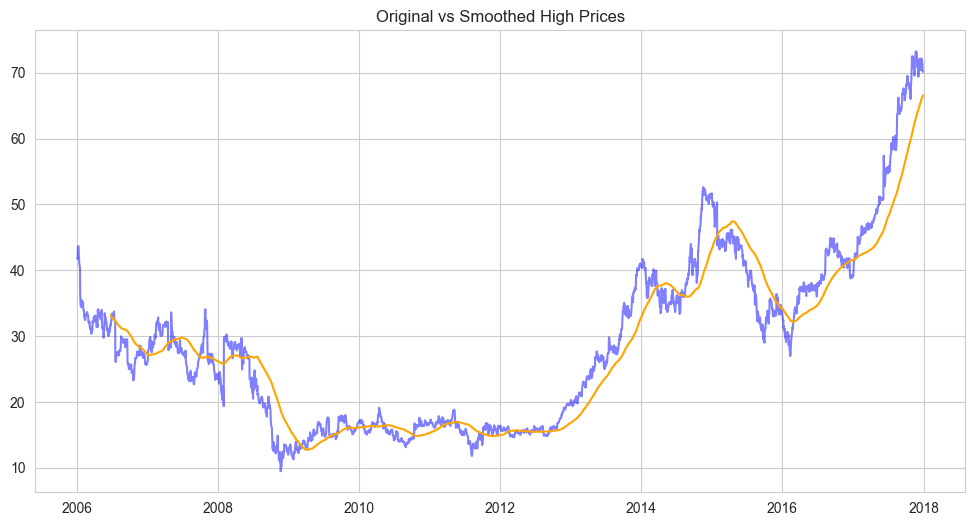

In [ ]:
window_size = 120
df['High_Smoothed'] = df['High'].rolling(window=window_size).mean()

plt.figure(figsize=(12, 6))

plt.plot(df['High'], label='Original High Prices', color='blue', alpha=0.5)
plt.plot(df['High_Smoothed'], label=f'Smoothed High Prices (Window={window_size})',  color='orange')
plt.title('Original vs Smoothed High Prices')
plt.show()

### Understanding the Rolling Method:

**What is the `rolling()` method?**
- The `rolling()` method creates a moving (or rolling) window that slides across the time series data
- At each position, it applies a specified function (like mean, sum, etc.) to the values within that window
- This technique is also called a "moving average" or "rolling average"

### How Rolling Average Works:

**Example with `window_size=3`:**

Original values: [10, 12, 15, 14, 13, 16, 18]

Rolling average calculation:
- Position 1: NaN (not enough data)
- Position 2: NaN (not enough data)
- Position 3: (10 + 12 + 15) / 3 = 12.33
- Position 4: (12 + 15 + 14) / 3 = 13.67
- Position 5: (15 + 14 + 13) / 3 = 14.00
- Position 6: (14 + 13 + 16) / 3 = 14.33
- Position 7: (13 + 16 + 18) / 3 = 15.67

Result: [NaN, NaN, 12.33, 13.67, 14.00, 14.33, 15.67]

### Interpreting the Smoothed Plot:

**What we can learn:**
1. **Trend Identification**: The smoothed line clearly shows the overall direction (upward, downward, or sideways)
2. **Noise Reduction**: Daily volatility is filtered out, making patterns easier to see
3. **Support/Resistance Levels**: The smoothed line can act as dynamic support or resistance in trading
4. **Pattern Recognition**: Makes it easier to spot trend changes and reversals
5. **Lag Effect**: Note that the smoothed line lags behind rapid price changes (trade-off for smoothness)
6. **Window Size Impact**: A window of 120 days (≈4 months) captures medium-term trends while filtering short-term noise